# State Dynamics: Model vs Exact Evolution

For each system size and training time step Δt, we:
1. Sample random initial states ρ₀
2. Evolve with model: ρ_model(t) = U_model(t) ρ₀ U_model†(t)
3. Evolve with exact reference: ρ_exact(t) = U_exact(t) ρ₀ U_exact†(t)
4. Compare via state fidelity F(ρ_model(t), ρ_exact(t))

Systems 2–6 qubits: model predicts U(t) directly.
Systems 7–8 qubits: model predicts H_eff(t), U(t) computed via Magnus or Trotter.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from req_prog.architectures import UnitaryModel
from req_prog.useful_functions import random_state, fidelity
from req_prog.h_torch import unitary_magnus_torch, unitary_trotter_torch

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_SMALL       = [2, 3, 4, 5, 6]           # direct unitary prediction
N_LARGE       = [7, 8]                     # via H_eff
N_ALL         = N_SMALL + N_LARGE
DELTA_T_LIST  = [0.1, 0.25, 0.5, 1.0]
LARGE_METHODS = ["magnus", "trotter"]      # both variants for 7-8 qubits
N_TIME        = 100
N_STATES      = 5 
STEPS         = 10                         # integration steps for Magnus/Trotter
SEED          = 42
np.random.seed(SEED)

In [3]:
def load_model_small(n_qubits: int, delta_t: float) -> torch.nn.Module:
    model = UnitaryModel(n_qubits=n_qubits)
    path  = f"models/models-full-loss/model{n_qubits}_deltat-{delta_t}.pth"
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    return model


def load_model_large(n_qubits: int, delta_t: float, method: str) -> torch.nn.Module:
    model = UnitaryModel(n_qubits=n_qubits)
    path  = f"models/models-full-loss/model{n_qubits}_deltat-{delta_t}-{method}.pth"
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    return model


def evolve_state(rho0: np.ndarray, U: np.ndarray) -> np.ndarray:
    """Evolve density matrix: ρ(t) = U ρ₀ U†, renormalized."""
    rho = U @ rho0 @ np.conj(U).T
    return rho / np.trace(rho)


def get_U_model_small(
    model: torch.nn.Module, t: float
) -> np.ndarray:
    """Forward pass for small systems — returns (d, d) complex numpy array."""
    with torch.no_grad():
        t_tensor = torch.tensor([t], dtype=torch.float32)
        return model(t_tensor)[0].detach().numpy()


def get_U_model_large(
    model: torch.nn.Module, t: float, n: int, method: str, steps: int
) -> np.ndarray:
    """Forward pass + integration for large systems — returns (d, d) complex numpy array."""
    fn = unitary_magnus_torch if method == "magnus" else unitary_trotter_torch
    with torch.no_grad():
        t_tensor = torch.tensor([[t]], dtype=torch.float32)
        return fn(model=model, time=t_tensor, steps=steps, n=n)[0].detach().numpy()


def state_fidelity_trajectory(
    get_U_model,        # callable: t -> U_model (d, d)
    U_target: np.ndarray,
    n_qubits: int,
    n_states: int,
    n_time: int
) -> np.ndarray:
    """
    Compute state fidelity F(ρ_model(t), ρ_exact(t)) for random initial states.

    Returns
    -------
    np.ndarray
        Shape (n_states, n_time).
    """
    times     = np.linspace(0, 1, n_time)
    fid_array = np.zeros((n_states, n_time))
    rho0_list = [random_state(n_qubits=n_qubits) for _ in range(n_states)]

    for t_idx, t in enumerate(times):
        U_model = get_U_model(t)
        U_exact = U_target[t_idx]

        for s_idx, rho0 in enumerate(rho0_list):
            rho_model = evolve_state(rho0, U_model)
            rho_exact = evolve_state(rho0, U_exact)
            fid_array[s_idx, t_idx] = fidelity(rho_exact, rho_model, lib="numpy")

    return fid_array

In [4]:
# ── Run: small systems (2–6 qubits) ──────────────────────────────────────────
# results_small[n][dt] = fid_array (N_STATES, N_TIME)
results_small = {n: {} for n in N_SMALL}

for n in N_SMALL:
    U_target = np.load(f"dataframe/unitary_N{n}_test.npy")   # (100, d, d)
    for dt in DELTA_T_LIST:
        model       = load_model_small(n, dt)
        get_U       = lambda t, m=model: get_U_model_small(m, t)
        fid_arr     = state_fidelity_trajectory(get_U, U_target, n, N_STATES, N_TIME)
        results_small[n][dt] = fid_arr
        print(
            f"N={n}, Δt={dt}: "
            f"{fid_arr.mean():.5f} ± {fid_arr.std():.5f}"
        )

print("Small systems done.")

N=2, Δt=0.1: 0.99976 ± 0.00020
N=2, Δt=0.25: 0.99947 ± 0.00062
N=2, Δt=0.5: 0.99892 ± 0.00079
N=2, Δt=1.0: 0.99679 ± 0.00209
N=3, Δt=0.1: 0.99945 ± 0.00041
N=3, Δt=0.25: 0.99884 ± 0.00087
N=3, Δt=0.5: 0.99561 ± 0.00316
N=3, Δt=1.0: 0.99191 ± 0.00419
N=4, Δt=0.1: 0.99996 ± 0.00003
N=4, Δt=0.25: 0.99699 ± 0.00221
N=4, Δt=0.5: 0.99067 ± 0.00596
N=4, Δt=1.0: 0.97896 ± 0.01161
N=5, Δt=0.1: 0.99999 ± 0.00001
N=5, Δt=0.25: 0.99915 ± 0.00062
N=5, Δt=0.5: 0.99784 ± 0.00134
N=5, Δt=1.0: 0.99553 ± 0.00232
N=6, Δt=0.1: 0.99988 ± 0.00015
N=6, Δt=0.25: 0.99848 ± 0.00109
N=6, Δt=0.5: 0.99622 ± 0.00236
N=6, Δt=1.0: 0.99173 ± 0.00439
Small systems done.


In [5]:
# ── Run: large systems (7–8 qubits) ──────────────────────────────────────────
# results_large[n][method][dt] = fid_array (N_STATES, N_TIME)
results_large = {n: {m: {} for m in LARGE_METHODS} for n in N_LARGE}

for n in N_LARGE:
    U_target = np.load(f"dataframe/unitary_N{n}_test.npy")   # (100, d, d)
    for method in LARGE_METHODS:
        for dt in DELTA_T_LIST:
            model   = load_model_large(n, dt, method)
            get_U   = lambda t, m=model, meth=method: get_U_model_large(m, t, n, meth, STEPS)
            fid_arr = state_fidelity_trajectory(get_U, U_target, n, N_STATES, N_TIME)
            results_large[n][method][dt] = fid_arr
            print(
                f"N={n}, {method}, Δt={dt}: "
                f"{fid_arr.mean():.5f} ± {fid_arr.std():.5f}"
            )

print("Large systems done.")

N=7, magnus, Δt=0.1: 0.99954 ± 0.00027
N=7, magnus, Δt=0.25: 0.99938 ± 0.00036
N=7, magnus, Δt=0.5: 0.99931 ± 0.00041
N=7, magnus, Δt=1.0: 0.99745 ± 0.00154
N=7, trotter, Δt=0.1: 0.99953 ± 0.00027
N=7, trotter, Δt=0.25: 0.99939 ± 0.00035
N=7, trotter, Δt=0.5: 0.99931 ± 0.00041
N=7, trotter, Δt=1.0: 0.99588 ± 0.00254
N=8, magnus, Δt=0.1: 0.99938 ± 0.00033
N=8, magnus, Δt=0.25: 0.99890 ± 0.00065
N=8, magnus, Δt=0.5: 0.99879 ± 0.00073
N=8, magnus, Δt=1.0: 0.99791 ± 0.00098
N=8, trotter, Δt=0.1: 0.99894 ± 0.00081
N=8, trotter, Δt=0.25: 0.99850 ± 0.00091
N=8, trotter, Δt=0.5: 0.99836 ± 0.00096
N=8, trotter, Δt=1.0: 0.99514 ± 0.00184
Large systems done.


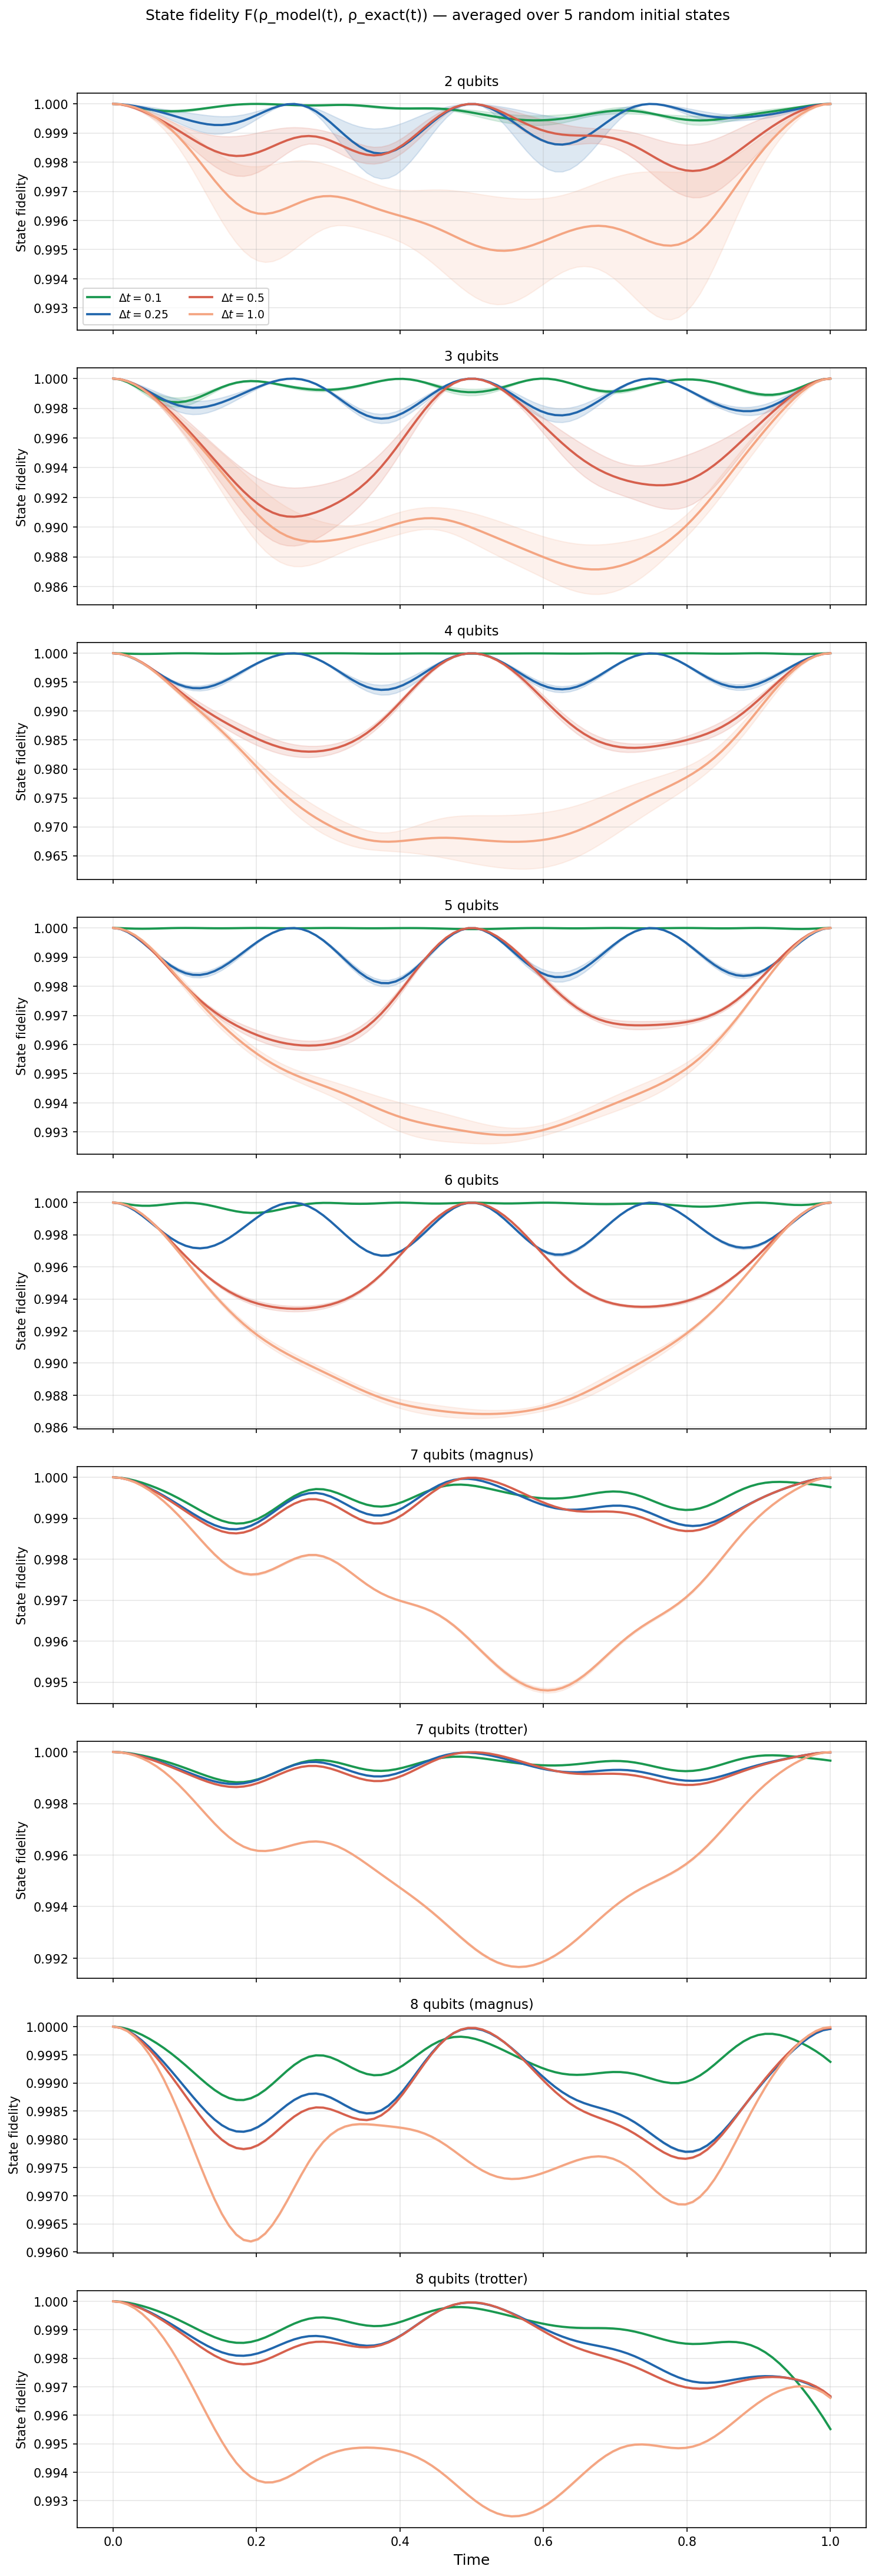

Figure saved to figures/state_dynamics_fidelity.pdf


In [6]:
# ── Figure 1: fidelity trajectories for all system sizes ─────────────────────
# For 7-8 qubits we show Magnus and Trotter as separate rows

times = np.linspace(0, 1, N_TIME)

colors_dt = {
    0.1 : "#1a9850",
    0.25: "#2166ac",
    0.5 : "#d6604d",
    1.0 : "#f4a582"
}
dt_labels = {
    0.1 : r"$\Delta t = 0.1$",
    0.25: r"$\Delta t = 0.25$",
    0.5 : r"$\Delta t = 0.5$",
    1.0 : r"$\Delta t = 1.0$"
}

# Row layout: one row per small system + two rows per large system (magnus, trotter)
row_specs = []
for n in N_SMALL:
    row_specs.append({"n": n, "label": f"{n} qubits"})
for n in N_LARGE:
    for method in LARGE_METHODS:
        row_specs.append({"n": n, "label": f"{n} qubits ({method})", "method": method})

n_rows = len(row_specs)
fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(10, 3.2 * n_rows),
    dpi=150, sharex=True
)

for row, spec in enumerate(row_specs):
    ax = axes[row]
    n  = spec["n"]

    for dt in DELTA_T_LIST:
        if n in N_SMALL:
            fid_arr = results_small[n][dt]
        else:
            fid_arr = results_large[n][spec["method"]][dt]

        mean = fid_arr.mean(axis=0)
        std  = fid_arr.std(axis=0)

        ax.plot(times, mean, color=colors_dt[dt], label=dt_labels[dt], lw=1.8)
        ax.fill_between(
            times, mean - std, mean + std,
            color=colors_dt[dt], alpha=0.15
        )

    ax.set_ylabel("State fidelity", fontsize=10)
    ax.set_title(spec["label"], fontsize=11)
    # ax.set_ylim([0.88, 1.01])
    ax.grid(alpha=0.3)
    if row == 0:
        ax.legend(fontsize=9, ncol=2)

axes[-1].set_xlabel("Time", fontsize=12)
plt.suptitle(
    f"State fidelity F(ρ_model(t), ρ_exact(t)) — averaged over {N_STATES} random initial states",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("figures/state_dynamics_fidelity.pdf", bbox_inches="tight")
plt.show()
print("Figure saved to figures/state_dynamics_fidelity.pdf")

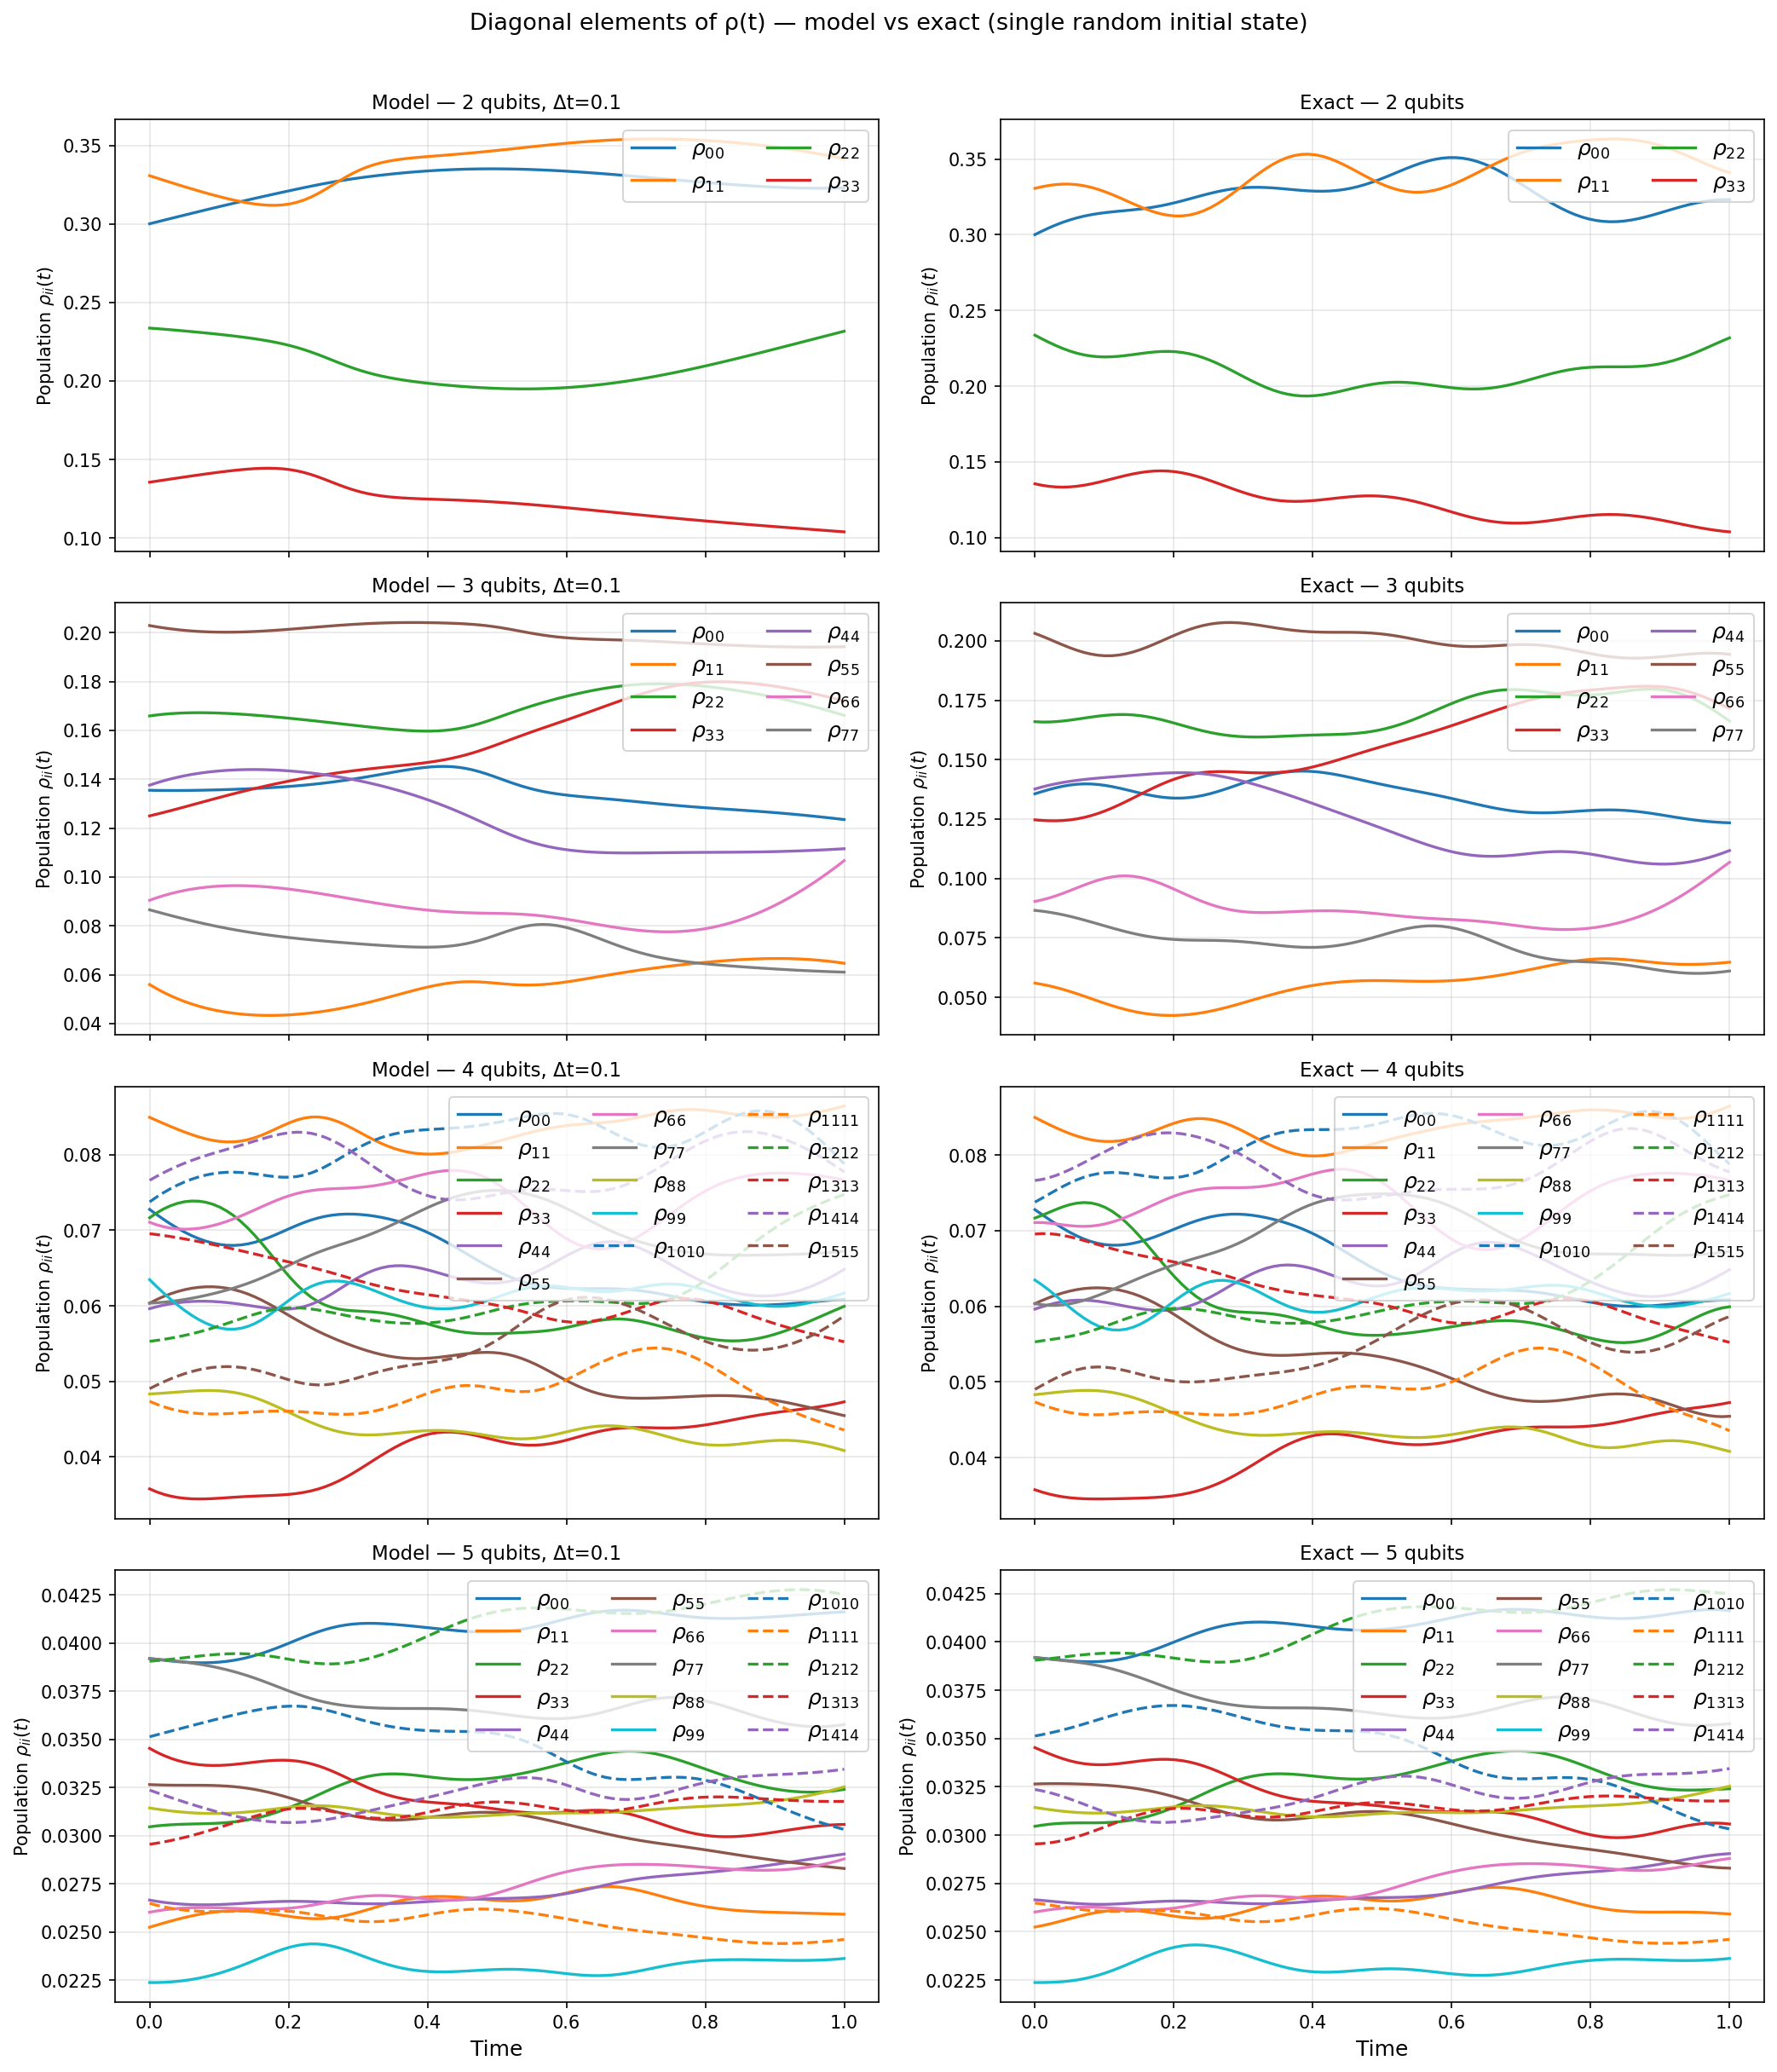

Figure saved to figures/state_dynamics_populations_2to5.pdf


In [9]:
# ── Figure 2: diagonal elements ρ_ii(t) — model vs exact, all system sizes ────
DT_EXAMPLE = 0.1
np.random.seed(0)

N_ALL      = [2, 3, 4, 5]
MAX_COMPS  = {2: 4, 3: 8, 4: 16, 5: 15, 6: 15, 7: 15, 8: 15}

# Line styles to differentiate components when colors repeat
linestyles = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,1)), (0,(1,1))]

fig, axes = plt.subplots(len(N_ALL), 2,
                         figsize=(14, 4 * len(N_ALL)),
                         dpi=150, sharex=True)

for row, n in enumerate(N_ALL):
    np.random.seed(0)  # same initial state for all systems
    d         = 2 ** n
    n_show    = MAX_COMPS[n]
    cmap      = plt.get_cmap("tab10")

    rho0_ex    = random_state(n_qubits=n)
    U_target   = np.load(f"dataframe/unitary_N{n}_test.npy")

    diag_model = np.zeros((N_TIME, d))
    diag_exact = np.zeros((N_TIME, d))

    if n <= 6:
        model_ex = load_model_small(n, DT_EXAMPLE)
        for t_idx, t in enumerate(np.linspace(0, 1, N_TIME)):
            U_model = get_U_model_small(model_ex, t)
            U_exact = U_target[t_idx]
            diag_model[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_model)))
            diag_exact[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_exact)))
    else:
        for method in ("magnus",):   # use magnus for illustration
            model_ex = load_model_large(n, DT_EXAMPLE, method)
            for t_idx, t in enumerate(np.linspace(0, 1, N_TIME)):
                U_model = get_U_model_large(model_ex, t, n, method, STEPS)
                U_exact = U_target[t_idx]
                diag_model[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_model)))
                diag_exact[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_exact)))

    times = np.linspace(0, 1, N_TIME)
    ax_m  = axes[row, 0]
    ax_e  = axes[row, 1]

    for i in range(n_show):
        color = cmap(i % 10)
        ls    = linestyles[(i // 10) % len(linestyles)]
        lbl   = f"$\\rho_{{{i}{i}}}$"
        ax_m.plot(times, diag_model[:, i], color=color, ls=ls, lw=1.6, label=lbl)
        ax_e.plot(times, diag_exact[:, i], color=color, ls=ls, lw=1.6, label=lbl)

    for ax, title in zip(
        [ax_m, ax_e],
        [f"Model — {n} qubits, Δt={DT_EXAMPLE}",
         f"Exact — {n} qubits"]
    ):
        ax.set_ylabel(r"Population $\rho_{ii}(t)$", fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.grid(alpha=0.3)
        ncol = 2 if n_show <= 8 else 3
        ax.legend(fontsize=12, ncol=ncol, loc="upper right")

axes[-1, 0].set_xlabel("Time", fontsize=12)
axes[-1, 1].set_xlabel("Time", fontsize=12)

plt.suptitle(
    "Diagonal elements of ρ(t) — model vs exact (single random initial state)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("figures/state_dynamics_populations_2to5.pdf", bbox_inches="tight")
plt.show()
print("Figure saved to figures/state_dynamics_populations_2to5.pdf")

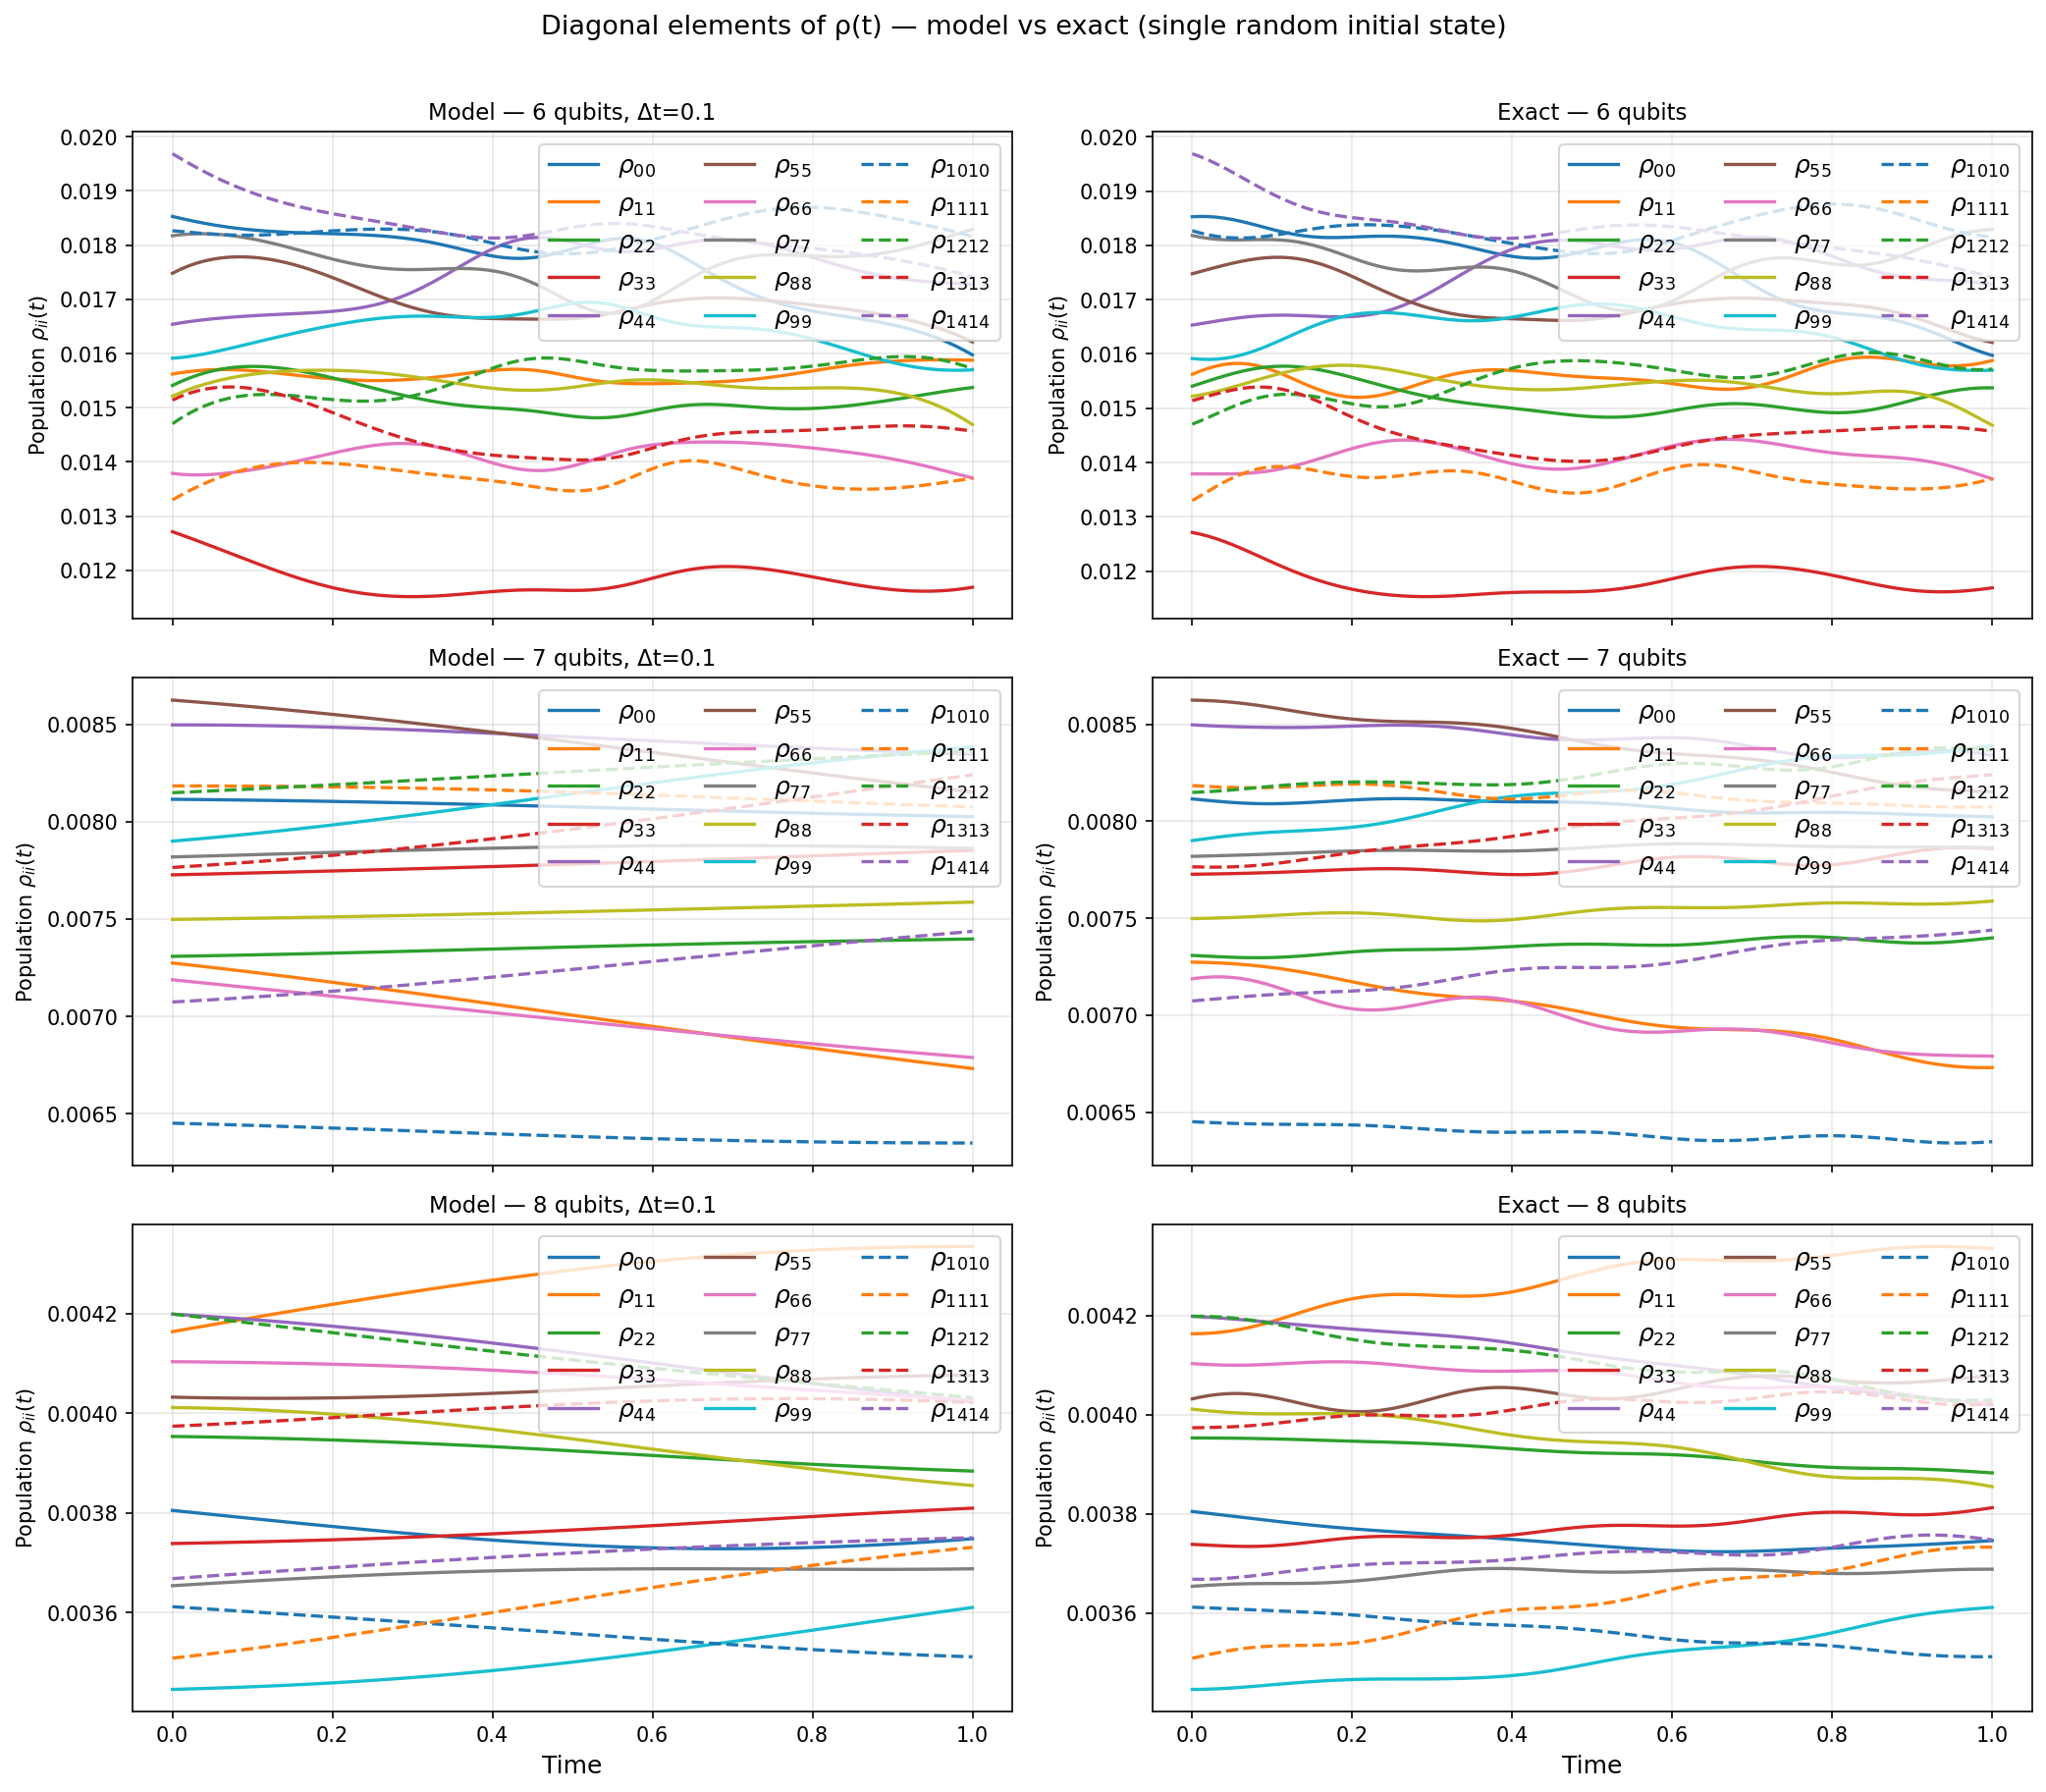

Figure saved to figures/state_dynamics_populations_6to8.pdf


In [10]:
# ── Figure 2: diagonal elements ρ_ii(t) — model vs exact, all system sizes ────
DT_EXAMPLE = 0.1
np.random.seed(0)

N_ALL      = [6, 7, 8]
MAX_COMPS  = {2: 4, 3: 8, 4: 16, 5: 15, 6: 15, 7: 15, 8: 15}

# Line styles to differentiate components when colors repeat
linestyles = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,1)), (0,(1,1))]

fig, axes = plt.subplots(len(N_ALL), 2,
                         figsize=(14, 4 * len(N_ALL)),
                         dpi=150, sharex=True)

for row, n in enumerate(N_ALL):
    np.random.seed(0)  # same initial state for all systems
    d         = 2 ** n
    n_show    = MAX_COMPS[n]
    cmap      = plt.get_cmap("tab10")

    rho0_ex    = random_state(n_qubits=n)
    U_target   = np.load(f"dataframe/unitary_N{n}_test.npy")

    diag_model = np.zeros((N_TIME, d))
    diag_exact = np.zeros((N_TIME, d))

    if n <= 6:
        model_ex = load_model_small(n, DT_EXAMPLE)
        for t_idx, t in enumerate(np.linspace(0, 1, N_TIME)):
            U_model = get_U_model_small(model_ex, t)
            U_exact = U_target[t_idx]
            diag_model[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_model)))
            diag_exact[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_exact)))
    else:
        for method in ("magnus",):   # use magnus for illustration
            model_ex = load_model_large(n, DT_EXAMPLE, method)
            for t_idx, t in enumerate(np.linspace(0, 1, N_TIME)):
                U_model = get_U_model_large(model_ex, t, n, method, STEPS)
                U_exact = U_target[t_idx]
                diag_model[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_model)))
                diag_exact[t_idx] = np.real(np.diag(evolve_state(rho0_ex, U_exact)))

    times = np.linspace(0, 1, N_TIME)
    ax_m  = axes[row, 0]
    ax_e  = axes[row, 1]

    for i in range(n_show):
        color = cmap(i % 10)
        ls    = linestyles[(i // 10) % len(linestyles)]
        lbl   = f"$\\rho_{{{i}{i}}}$"
        ax_m.plot(times, diag_model[:, i], color=color, ls=ls, lw=1.6, label=lbl)
        ax_e.plot(times, diag_exact[:, i], color=color, ls=ls, lw=1.6, label=lbl)

    for ax, title in zip(
        [ax_m, ax_e],
        [f"Model — {n} qubits, Δt={DT_EXAMPLE}",
         f"Exact — {n} qubits"]
    ):
        ax.set_ylabel(r"Population $\rho_{ii}(t)$", fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.grid(alpha=0.3)
        ncol = 2 if n_show <= 8 else 3
        ax.legend(fontsize=12, ncol=ncol, loc="upper right")

axes[-1, 0].set_xlabel("Time", fontsize=12)
axes[-1, 1].set_xlabel("Time", fontsize=12)

plt.suptitle(
    "Diagonal elements of ρ(t) — model vs exact (single random initial state)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("figures/state_dynamics_populations_6to8.pdf", bbox_inches="tight")
plt.show()
print("Figure saved to figures/state_dynamics_populations_6to8.pdf")